# labels_QuPath6 Radiusグラフで同種異種接続の解析
241115

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import radius_neighbors_graph

from glob import glob
import os
from tqdm import tqdm

In [2]:
pwd

'c:\\Users\\admin\\Documents\\東京大学 整形外科\\ヒト滑膜\\labels_QuPath6'

In [3]:
filepaths = glob("./tile_label_coord_241115/*txt")

In [4]:
df_dict = {}

for filepath in filepaths:
    samplename = os.path.basename(filepath)[:-7]
    df_dict[samplename] = pd.read_table(filepath, index_col=0)

In [5]:
# エッジ情報の保存先
edge_df_dict = {}

# 接続有りとする距離の閾値
radius = 80

for name, _df in df_dict.items():
    # XY座標取得
    points = _df[["x","y"]]

    adj_matrix = radius_neighbors_graph(X=points, radius=radius)
    edge_index = np.argwhere(adj_matrix > 0)

    # DataFrameに成型
    edge_df = pd.DataFrame(edge_index, columns=["edge_from","edge_to"])
    edge_df["id_from"] = _df.index[edge_df["edge_from"]]
    edge_df["id_to"] = _df.index[edge_df["edge_to"]]
    edge_df["label_from"] = _df.iloc[edge_df["edge_from"], _df.columns.get_loc("label") ].values
    edge_df["label_to"] = _df.iloc[edge_df["edge_to"], _df.columns.get_loc("label")].values

    edge_df_dict[name] = edge_df

In [6]:
edge_df_dict["D001"]

,edge_from,edge_to,id_from,id_to,label_from,label_to
0,0,2157,93414c62-72a8-4214-97d4-1bf91375e460,899fcd86-5997-4599-91df-c57274dec789,Immune cells,vessel
1,0,5520,93414c62-72a8-4214-97d4-1bf91375e460,bc8cc103-40bd-403e-8263-d65a88ca5a95,Immune cells,vessel
2,0,5827,93414c62-72a8-4214-97d4-1bf91375e460,0149eb96-a266-4434-ac5a-76f30c019b4f,Immune cells,"Fibro(dense,irregular)"
3,0,13449,93414c62-72a8-4214-97d4-1bf91375e460,17edffe8-7f61-4341-a894-02ae558d7dd2,Immune cells,plasma
4,0,20332,93414c62-72a8-4214-97d4-1bf91375e460,af92381b-d585-4231-bf0c-1bcb1d0c65a2,Immune cells,Fibro(loose)
...,...,...,...,...,...,...
574717,41019,17589,49f7f336-deeb-4427-b715-d183dc707d76,d3623249-09c6-4b47-a781-f20fdb7b5a6b,Fibro(loose),"Fibro(dense,irregular)"
574718,41019,17590,49f7f336-deeb-4427-b715-d183dc707d76,7f848343-2b63-4879-9f52-ca67f9f8b444,Fibro(loose),"Fibro(dense,irregular)"
574719,41019,27631,49f7f336-deeb-4427-b715-d183dc707d76,cab7a399-7e29-4c6b-9053-4c3beedeeef4,Fibro(loose),vessel
574720,41019,34670,49f7f336-deeb-4427-b715-d183dc707d76,4a5dab01-cd57-4b8c-a900-32fce12e6d1d,Fibro(loose),vessel


### Radiusグラフをローカルに書き出しておく

In [7]:
from matplotlib.backends.backend_pdf import PdfPages
import networkx as nx

# PDFファイルを作成
with PdfPages('radius_graph_241115.pdf') as pdf:

    for donor, _edge_df in tqdm(edge_df_dict.items()):
        _edge_index = _edge_df[["edge_from","edge_to"]]
        _df = df_dict[donor]
        _points = _df[["x","y"]].copy()
        _points["y"] = -_points["y"]
        plt.figure(figsize=(50,40))
        graph = nx.from_edgelist(_edge_index.values)
        nx.draw(graph, pos=_points.to_numpy(), node_size=1)
        plt.title(donor)
        # plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()


100%|██████████| 118/118 [11:17<00:00,  5.74s/it]


In [8]:
def get_neighbors(
    center_node, edge_index=None, adj_marix=None
):
    # edge_indexの指定がある場合
    if edge_index is not None:
        if edge_index.shape[0] < edge_index.shape[1]:
            edge_index = edge_index.T

        neighbor_nodes = edge_index[edge_index[:,0] == center_node][:,1]

    # 隣接行列の指定がある場合
    if adj_marix is not None:
        neighbor_nodes = np.where(adj_matrix[center_node,:])[0]

    return neighbor_nodes

In [9]:
from collections import Counter
import os

dirname = "tile_info_241115"
os.makedirs(dirname, exist_ok=True)


cell_type_levels = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "Fibro(Perivascular)", "lining", "vessel", "vessel(large)",
"adipose", "nerve", "Stroma", "muscle", "RBC"]

for donor, _df in tqdm(df_dict.items()) :

    num_nodes = _df.shape[0]
    edge_df = edge_df_dict[donor]
    edge_index = edge_df[["edge_from","edge_to"]].to_numpy()
    degrees = []
    purities = []
    entropies = []

    for i in range(num_nodes):
        center_celltype = _df.iloc[i]["label"]
        # 隣接ノードを取得
        neighbors = get_neighbors(center_node=i, edge_index=edge_index)
        degrees.append(len(neighbors))

        # 隣接ノードがあれば
        if len(neighbors) > 0:
            # 集計結果の保存先
            count_dict = { celltype:0 for celltype in cell_type_levels }
            count_dict[center_celltype] += 1
            # 集計
            count_dict.update( Counter(_df.iloc[neighbor]["label"] for neighbor in neighbors) )
        
            # 中心 + 隣接ノードの集合で最頻ラベル
            mode_label = max(count_dict, key=count_dict.get)
            # 中心 + 隣接ノードの最頻ラベルの純度
            purity = count_dict[mode_label] / sum(count_dict.values())

            # ラベルの登場確率
            total_count = sum(count_dict.values())
            probabilities = [ count / total_count for count in count_dict.values()]

            # エントロピーの計算
            entropy = -sum([p * np.log(p) for p in probabilities if p > 0])

        # 隣接ノードが無ければ
        else:
            purity = np.nan
            entropy = np.nan

        purities.append(purity)
        entropies.append(entropy)

    _df["Degree"] = degrees
    _df["Purity"] = purities
    _df["Entropy"] = entropies

    # 書き出し
    _df.to_csv(f"{dirname}/{donor}.txt",sep="\t",index_label="ID")


100%|██████████| 118/118 [36:19<00:00, 18.47s/it] 


## 平均化フィルターをかます

In [10]:
def mean_filter(
    metrics,
    num_nodes=None,
    edge_index=None,
    adj_matrix=None
):
    if isinstance(metrics,list):
        metrics = np.array(metrics)

    num_nodes = metrics.shape[0]

    mean_values = []
    for i in range(num_nodes):
        neighbors = get_neighbors(i,edge_index,adj_matrix)
        center_value = metrics[i]

        if len(neighbors) > 0:
            neighbor_values = metrics[neighbors]
            mean = np.mean(np.append(neighbor_values,center_value))
        else:
            mean = center_value

        mean_values.append(mean)

    return mean_values

In [11]:
from collections import Counter
import os

dirname = "tile_info_241115"
os.makedirs(dirname, exist_ok=True)


cell_type_levels = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "Fibro(Perivascular)", "lining", "vessel", "vessel(large)",
"adipose", "nerve", "Stroma", "muscle", "RBC"]

for donor, _df in tqdm(df_dict.items()) :

    num_nodes = _df.shape[0]
    edge_df = edge_df_dict[donor]
    edge_index = edge_df[["edge_from","edge_to"]].to_numpy()

    _df["Purity_mean"] = mean_filter(_df["Purity"].values, edge_index=edge_index)
    _df["Entropy_mean"] = mean_filter(_df["Entropy"].values, edge_index=edge_index)

    # 書き出し
    _df.to_csv(f"{dirname}/{donor}.txt",sep="\t",index_label="ID")


100%|██████████| 118/118 [49:19<00:00, 25.08s/it]  


## データ分布

(array([1126.,  870., 1454., 4236., 6255., 8443., 9145., 6582., 2423.,
         486.]),
 array([0.        , 0.17042419, 0.34084838, 0.51127257, 0.68169676,
        0.85212095, 1.02254514, 1.19296933, 1.36339352, 1.53381771,
        1.7042419 ]),
 <BarContainer object of 10 artists>)

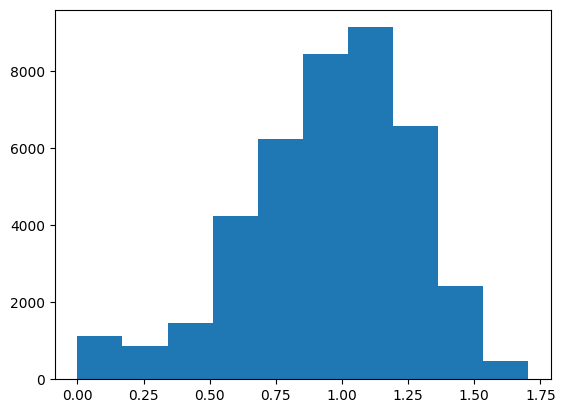

In [12]:
plt.hist( df_dict["D001"]["Entropy_mean"])

In [13]:
from scipy.stats import gaussian_kde

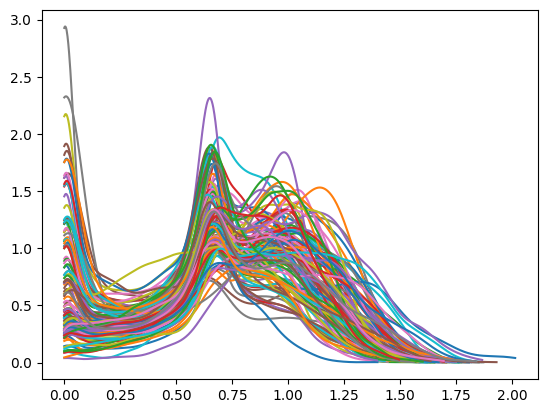

In [14]:
for donor, _df in df_dict.items():
    data = _df["Entropy_mean"]
    data = data.dropna()
    density =gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 1000)
    plt.plot(x, density(x), label='密度曲線')

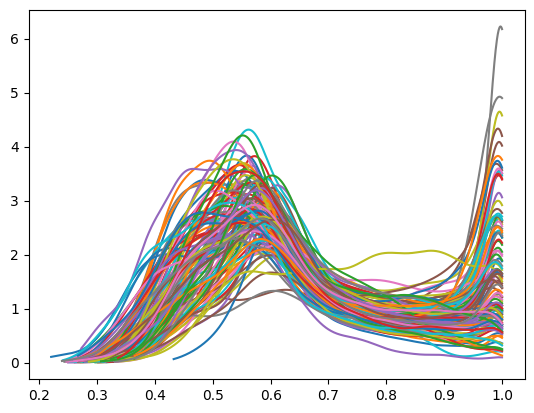

In [15]:
for donor, _df in df_dict.items():
    data = _df["Purity_mean"]
    data = data.dropna()
    density =gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 1000)
    plt.plot(x, density(x), label='密度曲線')

## 密度曲線でクラスタリング

In [16]:
import numpy as np
from scipy.stats import gaussian_kde

# 全ての密度曲線を同じX軸にグリッド化する
x_grid = np.linspace(0,2,100)

# 各データセットに対して密度推定を行い、同じx_grid上で評価する
densities = []
for donor, _df in df_dict.items():
    data = _df["Entropy_mean"]
    data = data.dropna()
    density = gaussian_kde(data)
    densities.append(density(x_grid))


### コサイン類似度

In [17]:
from numpy import dot
from numpy.linalg import norm

n = len(densities)

# コサイン類似度の距離行列を作成
cosine_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        cosine_similarity = dot(densities[i], densities[j]) / (norm(densities[i]) * norm(densities[j]))
        cosine_matrix[i, j] = cosine_similarity  # 類似度を距離に変換

In [18]:
import os
os.makedirs("plots", exist_ok=True)

c:\Users\admin\anaconda3\envs\PyG\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\admin\anaconda3\envs\PyG\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


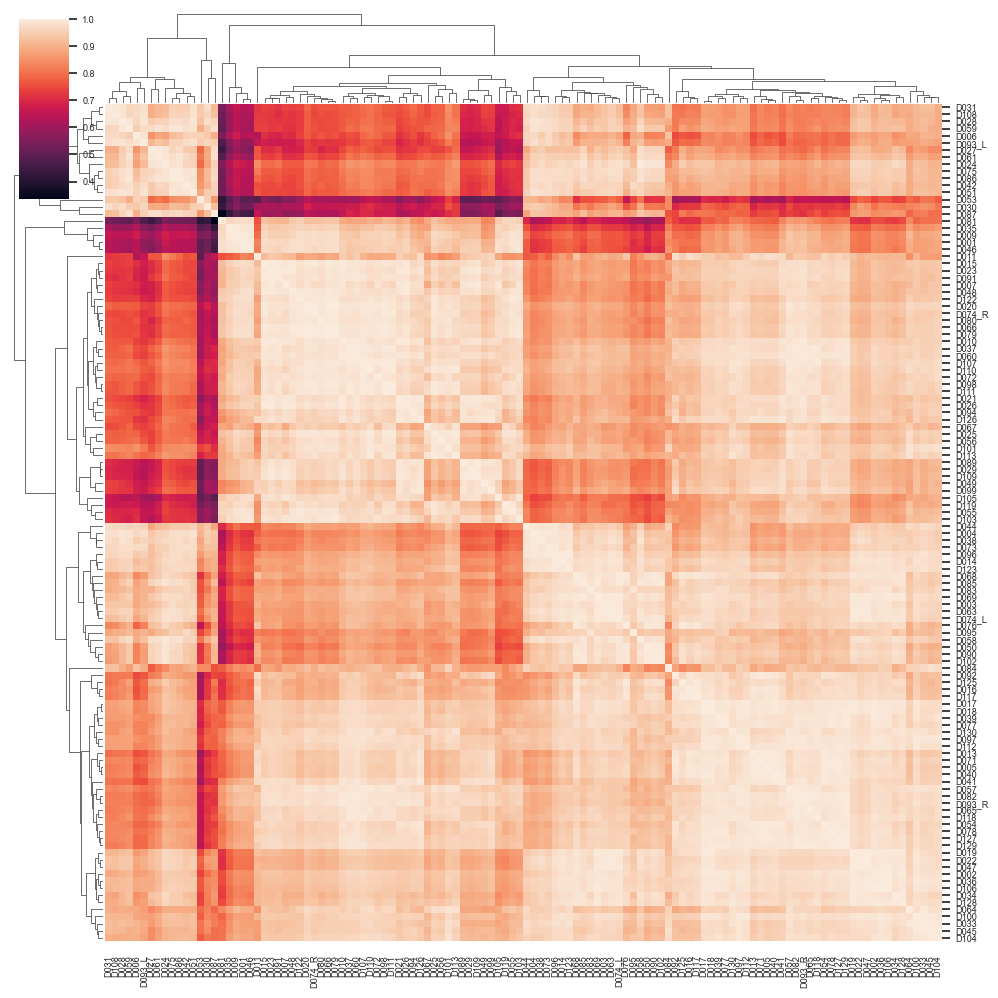

In [19]:
cosine_matrix = pd.DataFrame(cosine_matrix, index=df_dict.keys(), columns=df_dict.keys())

sns.set(font_scale=0.6)
p = sns.clustermap(cosine_matrix, figsize=(10,10),xticklabels=1,yticklabels=1, dendrogram_ratio=(0.1,0.1),)
p.savefig("plots/001_Entropy_density_cosinesimilality_241115.pdf", format="pdf")

### 集団ごとの分布を確認してみる

In [20]:
cosine_matrix.index[p.dendrogram_col.reordered_ind]

Index(['D031', 'D108', 'D028', 'D059', 'D006', 'D093_L', 'D027', 'D061',
       'D024', 'D075',
       ...
       'D002', 'D036', 'D106', 'D034', 'D128', 'D064', 'D100', 'D033', 'D045',
       'D104'],
      dtype='object', length=118)

In [27]:
cosine_matrix.index[p.dendrogram_col.reordered_ind][0:16]

Index(['D031', 'D108', 'D028', 'D059', 'D006', 'D093_L', 'D027', 'D061',
       'D024', 'D075', 'D086', 'D042', 'D051', 'D053', 'D030', 'D087'],
      dtype='object')

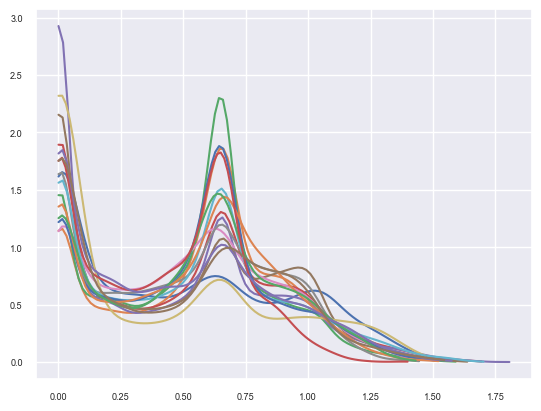

In [28]:
donors = cosine_matrix.index[p.dendrogram_col.reordered_ind][0:16]

for donor, _df in df_dict.items():
    if donor in donors:
        data = _df["Entropy_mean"]
        data = data.dropna()
        density =gaussian_kde(data)
        x = np.linspace(data.min(), data.max(), 100)
        plt.plot(x, density(x), label='密度曲線')

#### --> ホモ接続が多い奴らかな?

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイル名
output_pdf = "plots/002_density_cluster1.pdf"

donors = cosine_matrix.index[p.dendrogram_col.reordered_ind][0:16]

# PDFの準備
with PdfPages(output_pdf) as pdf:
    plt.figure(figsize=(10, 6))  # グラフのサイズを調整

    # 密度曲線をプロット
    for donor, _df in df_dict.items():
        if donor in donors:
            data = _df["Entropy_mean"].dropna()
            density = gaussian_kde(data)
            x = np.linspace(data.min(), data.max(), 100)
            plt.plot(x, density(x), label=f'{donor}')

    # プロットの設定
    plt.xlabel("X-axis Label")
    plt.ylabel("Density")
    plt.title("Overlayed Density Plots")

    # 凡例を右側に配置
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', ncol=1)
    plt.grid(True)

    # PDFに保存
    pdf.savefig(bbox_inches='tight')  # 凡例が表示されるようにPDFの余白を調整
    plt.close()  # 現在のFigureを閉じる


In [30]:
cosine_matrix.index[p.dendrogram_col.reordered_ind][17:59]

Index(['D035', 'D009', 'D001', 'D046', 'D011', 'D015', 'D023', 'D091', 'D007',
       'D048', 'D122', 'D020', 'D074_R', 'D080', 'D066', 'D079', 'D010',
       'D037', 'D060', 'D107', 'D110', 'D072', 'D098', 'D111', 'D021', 'D026',
       'D094', 'D126', 'D067', 'D025', 'D056', 'D101', 'D113', 'D089', 'D029',
       'D109', 'D049', 'D099', 'D105', 'D119', 'D055', 'D103'],
      dtype='object')

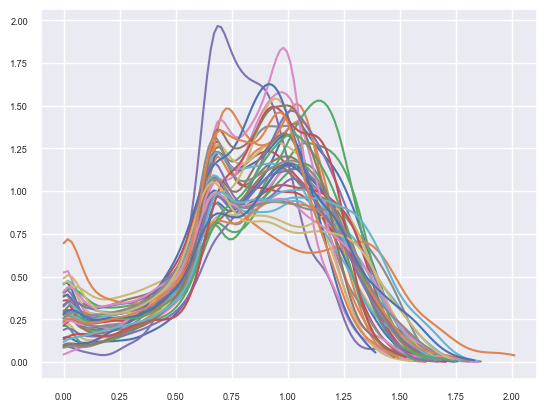

In [31]:
donors = cosine_matrix.index[p.dendrogram_col.reordered_ind][17:59]

for donor, _df in df_dict.items():
    if donor in donors:
        data = _df["Entropy_mean"]
        data = data.dropna()
        density =gaussian_kde(data)
        x = np.linspace(data.min(), data.max(), 100)
        plt.plot(x, density(x), label='密度曲線')

#### --> ヘテロ接続頻度が多い患者群

In [37]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイル名
output_pdf = "plots/002_density_cluster2.pdf"

donors = cosine_matrix.index[p.dendrogram_col.reordered_ind][17:59]

# PDFの準備
with PdfPages(output_pdf) as pdf:
    plt.figure(figsize=(10, 6))  # グラフのサイズを調整

    # 密度曲線をプロット
    for donor, _df in df_dict.items():
        if donor in donors:
            data = _df["Entropy_mean"].dropna()
            density = gaussian_kde(data)
            x = np.linspace(data.min(), data.max(), 100)
            plt.plot(x, density(x), label=f'{donor}')

    # プロットの設定
    plt.xlabel("X-axis Label")
    plt.ylabel("Density")
    plt.title("Overlayed Density Plots")
    
    # 凡例を右側に配置
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', ncol=1)
    plt.grid(True)
    
    # PDFに保存
    pdf.savefig(bbox_inches='tight')  # 凡例が表示されるようにPDFの余白を調整
    plt.close()  # 現在のFigureを閉じる


In [38]:
cosine_matrix.index[p.dendrogram_col.reordered_ind][59:]

Index(['D044', 'D004', 'D038', 'D073', 'D096', 'D014', 'D123', 'D068', 'D085',
       'D083', 'D069', 'D003', 'D063', 'D074_L', 'D076', 'D095', 'D058',
       'D050', 'D090', 'D102', 'D084', 'D092', 'D125', 'D016', 'D117', 'D017',
       'D018', 'D039', 'D077', 'D130', 'D097', 'D112', 'D013', 'D071', 'D005',
       'D040', 'D041', 'D057', 'D082', 'D093_R', 'D065', 'D118', 'D054',
       'D078', 'D127', 'D129', 'D019', 'D022', 'D047', 'D002', 'D036', 'D106',
       'D034', 'D128', 'D064', 'D100', 'D033', 'D045', 'D104'],
      dtype='object')

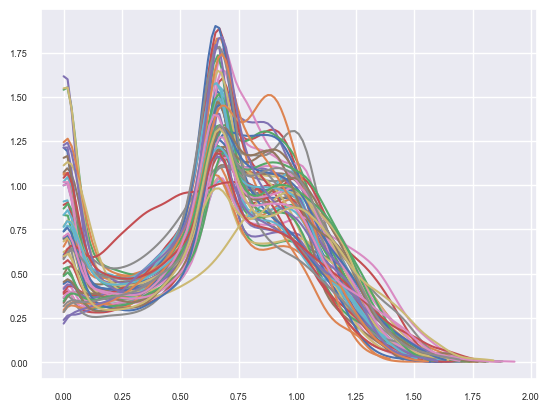

In [39]:
donors = cosine_matrix.index[p.dendrogram_col.reordered_ind][59:]

for donor, _df in df_dict.items():
    if donor in donors:
        data = _df["Entropy_mean"]
        data = data.dropna()
        density =gaussian_kde(data)
        x = np.linspace(data.min(), data.max(), 100)
        plt.plot(x, density(x), label='密度曲線')

In [40]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイル名
output_pdf = "plots/002_density_cluster3.pdf"

donors = cosine_matrix.index[p.dendrogram_col.reordered_ind][59:]

# PDFの準備
with PdfPages(output_pdf) as pdf:
    plt.figure(figsize=(10, 6))  # グラフのサイズを調整

    # 密度曲線をプロット
    for donor, _df in df_dict.items():
        if donor in donors:
            data = _df["Entropy_mean"].dropna()
            density = gaussian_kde(data)
            x = np.linspace(data.min(), data.max(), 100)
            plt.plot(x, density(x), label=f'{donor}')

    # プロットの設定
    plt.xlabel("X-axis Label")
    plt.ylabel("Density")
    plt.title("Overlayed Density Plots")
    
    # 凡例を右側に配置
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', ncol=2)
    plt.grid(True)
    
    # PDFに保存
    pdf.savefig(bbox_inches='tight')  # 凡例が表示されるようにPDFの余白を調整
    plt.close()  # 現在のFigureを閉じる


# 同種接続、異種接続の次数計算

In [41]:
AdjMat_dict = {}

cluster_level = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

for name, _edge_df in tqdm(edge_df_dict.items()):

    # 接続先の一時集計先
    neighbor_cluster_num = {}

    for cluster in cluster_level:
        # 接続元ノードがclusterのエッジを取得
        edge_subset = _edge_df[ _edge_df['label_from'] == cluster]

        # 接続先のclusterを集計
        cluster_counts = {key: 0 for key in cluster_level}
        cluster_counts.update(edge_subset['label_to'].value_counts().to_dict())
        neighbor_cluster_num[cluster] = cluster_counts

    # 隣接行列を作成
    AdjMat = pd.DataFrame(neighbor_cluster_num)
    # 総edge数で補正
    AdjMat = AdjMat / _edge_df.shape[0]

    AdjMat_dict[name] = AdjMat

100%|██████████| 118/118 [00:17<00:00,  6.59it/s]


In [42]:
AdjMat.sum().sum()

np.float64(1.0)

In [43]:
## 全症例の結果を集計 (118*ラベル数*ラベル数)
AdjMat_array = np.stack(list(AdjMat_dict.values()))

In [44]:
AdjMat_array.shape

(118, 12, 12)

In [45]:
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイルを作成
with PdfPages('plots/003_label_pairwise_degree_ratio_241115.pdf') as pdf:

    for donor in AdjMat_dict.keys():
        plt.figure(figsize=(10,10))
        sns.heatmap(AdjMat_dict[donor],cmap="Greys",
            center=0.05, vmin=0, vmax=0.1, annot=True, fmt=".2f")
        plt.title(donor)
        plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()

### 対称行列を対角成分と上三角だけに修正

In [46]:
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイルを作成
with PdfPages('plots/004_label_pairwise_degree_ratio2_241115.pdf') as pdf:

    for donor in AdjMat_dict.keys():
        adjmat = AdjMat_dict[donor].copy()
        adjmat = pd.DataFrame(np.triu(adjmat) + np.triu(adjmat,k=1), index=adjmat.index, columns=adjmat.columns)
        plt.figure(figsize=(10,10))
        sns.heatmap(adjmat,cmap="Greys",
            center=0.1, vmin=0, vmax=0.2, annot=True, fmt=".2f")
        plt.title(donor)
        plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()

### 下三角 NaN版

In [47]:
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイルを作成
with PdfPages('plots/005_label_pairwise_degree_ratio3_241115.pdf') as pdf:

    for donor in AdjMat_dict.keys():
        adjmat = AdjMat_dict[donor].copy()
        adjmat = pd.DataFrame(np.triu(adjmat) + np.triu(adjmat,k=1), index=adjmat.index, columns=adjmat.columns)
        adjmat.values[ np.tril_indices_from(adjmat, k=-1) ] = np.nan
        plt.figure(figsize=(10,10))
        sns.heatmap(adjmat,cmap="Greys",
            center=0.1, vmin=0, vmax=0.2, annot=True, fmt=".2f")
        plt.title(donor)
        plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()

### ヘテロ接続のみで比率計算

In [48]:
AdjMat_dict2 = {}

for name, _edge_df in edge_df_dict.items():

    # 接続先の一時集計先
    neighbor_cluster_num = {}

    for cluster in cluster_level:
        # 接続元ノードがclusterのエッジを取得
        edge_subset = _edge_df[ _edge_df['label_from'] == cluster]

        # 接続先のclusterを集計
        cluster_counts = {key: 0 for key in cluster_level}
        cluster_counts.update(edge_subset['label_to'].value_counts().to_dict())
        neighbor_cluster_num[cluster] = cluster_counts

    # 隣接行列を作成
    AdjMat = pd.DataFrame(neighbor_cluster_num)
    AdjMat_upper = pd.DataFrame(np.triu(AdjMat,k=1) + np.triu(AdjMat,k=1),
                                index=AdjMat.index, columns=AdjMat.columns)
    AdjMat_upper = AdjMat_upper / AdjMat_upper.sum().sum()


    AdjMat_dict2[name] = AdjMat_upper

In [49]:
AdjMat_upper.sum().sum()

np.float64(1.0)

In [50]:
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイルを作成
with PdfPages('plots/006_label_hetero_degree_ratio_241115.pdf') as pdf:

    for donor in AdjMat_dict2.keys():
        adjmat = AdjMat_dict2[donor].copy()
        adjmat.values[ np.tril_indices_from(adjmat) ] = np.nan
        plt.figure(figsize=(10,10))
        sns.heatmap(adjmat,cmap="Greys",
            center=0.1, vmin=0, vmax=0.2, annot=True, fmt=".2f")
        plt.title(donor)
        plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()

## Entropy cutoff以上のタイルで異種接続を集計
dfをフィルタリングしてグラフから作り直す必要があるか。

In [51]:
for donor, _df in df_dict.items():
    print(donor)
    print(_df[["Entropy_mean","Purity_mean"]].describe())

D001
       Entropy_mean   Purity_mean
count  41020.000000  41020.000000
mean       0.950764      0.561483
std        0.315980      0.139986
min        0.000000      0.258448
25%        0.755776      0.463258
50%        0.989352      0.537921
75%        1.176515      0.620217
max        1.704242      1.000000
D002
       Entropy_mean  Purity_mean
count   4763.000000  4763.000000
mean       0.670392     0.669429
std        0.366488     0.179888
min        0.000000     0.330252
25%        0.423402     0.532400
50%        0.691681     0.625343
75%        0.952155     0.808952
max        1.475243     1.000000
D003
       Entropy_mean   Purity_mean
count  46621.000000  46621.000000
mean       0.608777      0.709126
std        0.348213      0.178398
min        0.000000      0.297178
25%        0.342687      0.563216
50%        0.661862      0.673554
75%        0.881184      0.871268
max        1.653078      1.000000
D004
       Entropy_mean   Purity_mean
count  34970.000000  34970.000000
mea

#### --> 全サンプルで0.5以上のEntropyはあるね

In [52]:
_df[ _df["Entropy_mean"] >= 0.5 ]

,x,y,label,Degree,Purity,Entropy,Purity_mean,Entropy_mean
ID,,,,,,,,
2716d739-7d9b-4db3-bd31-bb1e86bce653,9166.070312,5845.279785,"Fibro(dense,irregular)",7,0.714286,0.598270,0.577886,0.671492
5bc9db9d-b244-4b04-a0fc-7d0565f06f6f,9148.330078,5872.310059,"Fibro(dense,irregular)",5,0.600000,0.673012,0.587013,0.670203
fdb2b6f0-8d96-4da7-89f8-e440ce239fa4,3646.830078,4583.330078,"Fibro(dense,irregular)",23,0.541667,1.095559,0.538864,1.032172
c65a0cf3-29e4-437b-9bf7-5cbe5748b375,1739.510010,6705.069824,"Fibro(dense,irregular)",15,0.666667,0.953271,0.470198,1.178816
36ee2565-6a7e-4d7d-b52d-ffc119ae8e07,3274.709961,5664.879883,"Fibro(dense,regular)",25,0.320000,1.287727,0.463163,1.166595
...,...,...,...,...,...,...,...,...
0d901c57-845f-4f15-9132-fa744e1bfcb2,4692.720215,6167.799805,lining,9,0.666667,0.636514,0.563059,0.764346
454a30ac-6c30-4bbf-b9b6-67add271eff0,4717.560059,6197.479980,lining,7,0.714286,0.598270,0.546356,0.794522
d4071d22-13b7-465c-8d5e-f139a6a9d0e3,4728.049805,6209.569824,lining,8,0.500000,0.974315,0.532451,0.828582


In [53]:
df_dict2 = {}

for donor, _df in df_dict.items():
    df_dict2[donor] = _df[ _df["Entropy_mean"] >= 0.5 ]

In [54]:
# エッジ情報の保存先
edge_df_dict2 = {}

# 接続有りとする距離の閾値
radius = 80

for name, _df in df_dict2.items():
    # XY座標取得
    points = _df[["x","y"]]

    adj_matrix = radius_neighbors_graph(X=points, radius=radius)
    edge_index = np.argwhere(adj_matrix > 0)

    # DataFrameに成型
    edge_df = pd.DataFrame(edge_index, columns=["edge_from","edge_to"])
    edge_df["id_from"] = _df.index[edge_df["edge_from"]]
    edge_df["id_to"] = _df.index[edge_df["edge_to"]]
    edge_df["label_from"] = _df.iloc[edge_df["edge_from"], _df.columns.get_loc("label") ].values
    edge_df["label_to"] = _df.iloc[edge_df["edge_to"], _df.columns.get_loc("label")].values

    edge_df_dict2[name] = edge_df

### 新Radiusグラフをローカルに書き出しておく

In [55]:
from matplotlib.backends.backend_pdf import PdfPages
import networkx as nx

# PDFファイルを作成
with PdfPages('plots/007_radius_graph_onlyhetero_241115.pdf') as pdf:

    for donor, _edge_df in edge_df_dict2.items():
        _edge_index = _edge_df[["edge_from","edge_to"]]
        _df = df_dict2[donor]
        _points = _df[["x","y"]].copy()
        _points["y"] = -_points["y"]
        plt.figure(figsize=(50,40))
        graph = nx.from_edgelist(_edge_index.values)
        nx.draw(graph, pos=_points.to_numpy(), node_size=1)
        plt.title(donor)
        # plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()

## 異種接続を集計

In [56]:
AdjMat_dict = {}

cluster_level = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

for name, _edge_df in tqdm(edge_df_dict2.items()):

    # 接続先の一時集計先
    neighbor_cluster_num = {}

    for cluster in cluster_level:
        # 接続元ノードがclusterのエッジを取得
        edge_subset = _edge_df[ _edge_df['label_from'] == cluster]

        # 接続先のclusterを集計
        cluster_counts = {key: 0 for key in cluster_level}
        cluster_counts.update(edge_subset['label_to'].value_counts().to_dict())
        neighbor_cluster_num[cluster] = cluster_counts

    # 隣接行列を作成
    AdjMat = pd.DataFrame(neighbor_cluster_num)
    # 総edge数で補正
    AdjMat = AdjMat / _edge_df.shape[0]

    AdjMat_dict[name] = AdjMat

100%|██████████| 118/118 [00:14<00:00,  8.02it/s]


In [57]:
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイルを作成
with PdfPages('plots/008_Entropy_filtered_label_pairwise_degree_ratio_241115.pdf') as pdf:

    for donor in AdjMat_dict.keys():
        plt.figure(figsize=(10,10))
        sns.heatmap(AdjMat_dict[donor],cmap="Greys",
            center=0.05, vmin=0, vmax=0.1, annot=True, fmt=".2f")
        plt.title(donor)
        plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()

### 対称行列を対角成分と上三角だけに修正

In [58]:
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイルを作成
with PdfPages('plots/009_Entropy_filtered_label_pairwise_degree_ratio2_241115.pdf') as pdf:

    for donor in AdjMat_dict.keys():
        adjmat = AdjMat_dict[donor].copy()
        adjmat = pd.DataFrame(np.triu(adjmat) + np.triu(adjmat,k=1), index=adjmat.index, columns=adjmat.columns)
        plt.figure(figsize=(10,10))
        sns.heatmap(adjmat,cmap="Greys",
            center=0.1, vmin=0, vmax=0.2, annot=True, fmt=".2f")
        plt.title(donor)
        plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()

### 下三角 NaN版

In [59]:
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイルを作成
with PdfPages('plots/010_Entropy_filtered_label_pairwise_degree_ratio3_241115.pdf') as pdf:

    for donor in AdjMat_dict.keys():
        adjmat = AdjMat_dict[donor].copy()
        adjmat = pd.DataFrame(np.triu(adjmat) + np.triu(adjmat,k=1), index=adjmat.index, columns=adjmat.columns)
        adjmat.values[ np.tril_indices_from(adjmat, k=-1) ] = np.nan
        plt.figure(figsize=(10,10))
        sns.heatmap(adjmat,cmap="Greys",
            center=0.1, vmin=0, vmax=0.2, annot=True, fmt=".2f")
        plt.title(donor)
        plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()

### ヘテロ接続のみで比率計算

In [60]:
AdjMat_dict2 = {}

for name, _edge_df in edge_df_dict2.items():

    # 接続先の一時集計先
    neighbor_cluster_num = {}

    for cluster in cluster_level:
        # 接続元ノードがclusterのエッジを取得
        edge_subset = _edge_df[ _edge_df['label_from'] == cluster]

        # 接続先のclusterを集計
        cluster_counts = {key: 0 for key in cluster_level}
        cluster_counts.update(edge_subset['label_to'].value_counts().to_dict())
        neighbor_cluster_num[cluster] = cluster_counts

    # 隣接行列を作成
    AdjMat = pd.DataFrame(neighbor_cluster_num)
    AdjMat_upper = pd.DataFrame(np.triu(AdjMat,k=1) + np.triu(AdjMat,k=1),
                                index=AdjMat.index, columns=AdjMat.columns)
    AdjMat_upper = AdjMat_upper / AdjMat_upper.sum().sum()


    AdjMat_dict2[name] = AdjMat_upper

In [61]:
from matplotlib.backends.backend_pdf import PdfPages

# PDFファイルを作成
with PdfPages('plots/011_Entropy_filtered_label_hetero_degree_ratio_241115.pdf') as pdf:

    for donor in AdjMat_dict2.keys():
        adjmat = AdjMat_dict2[donor].copy()
        adjmat.values[ np.tril_indices_from(adjmat) ] = np.nan
        plt.figure(figsize=(10,10))
        sns.heatmap(adjmat,cmap="Greys",
            center=0.1, vmin=0, vmax=0.2, annot=True, fmt=".2f")
        plt.title(donor)
        plt.tight_layout()  # レイアウト調整
        pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
        plt.close()  # プロットを閉じる

# 必要なら表示
plt.show()

## 次数比率でクラスタリング

In [62]:
adjmat.values[ np.triu_indices_from(adjmat) ].shape

(78,)

In [63]:
adjmat

,Immune cells,plasma,Fibro(loose),"Fibro(dense,regular)","Fibro(dense,irregular)",lining,vessel,vessel(large),adipose,Stroma,muscle,RBC
Immune cells,NaN,0.0,0.000234,0.000105,0.000573,0.000035,0.000222,0.000012,0.000421,0.000000,0.000012,0.000070
plasma,NaN,NaN,0.000058,0.000000,0.000000,0.000000,0.000012,0.000000,0.000082,0.000000,0.000000,0.000012
Fibro(loose),NaN,NaN,NaN,0.070568,0.215420,0.006978,0.034647,0.019030,0.120013,0.000713,0.122257,0.005961
"Fibro(dense,regular)",NaN,NaN,NaN,NaN,0.078049,0.002279,0.004874,0.005506,0.008241,0.000397,0.056050,0.000584
"Fibro(dense,irregular)",NaN,NaN,NaN,NaN,NaN,0.017101,0.040363,0.008755,0.059218,0.000245,0.033513,0.007060
lining,NaN,NaN,NaN,NaN,NaN,NaN,0.001777,0.001344,0.000351,0.000129,0.004898,0.000421
vessel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002385,0.015745,0.000105,0.007060,0.004231
vessel(large),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004185,0.000000,0.024033,0.000374
adipose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.007937,0.002385
Stroma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000959,0.000070


In [64]:
adjmat.values[ np.triu_indices_from(adjmat) ]

array([           nan, 0.00000000e+00, 2.33784147e-04, 1.05202866e-04,
       5.72771160e-04, 3.50676221e-05, 2.22094940e-04, 1.16892074e-05,
       4.20811465e-04, 0.00000000e+00, 1.16892074e-05, 7.01352441e-05,
                  nan, 5.84460368e-05, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.16892074e-05, 0.00000000e+00, 8.18244515e-05,
       0.00000000e+00, 0.00000000e+00, 1.16892074e-05,            nan,
       7.05677448e-02, 2.15420402e-01, 6.97845679e-03, 3.46468106e-02,
       1.90300296e-02, 1.20013092e-01, 7.13041649e-04, 1.22257420e-01,
       5.96149575e-03,            nan, 7.80488375e-02, 2.27939543e-03,
       4.87439947e-03, 5.50561666e-03, 8.24089119e-03, 3.97433050e-04,
       5.60497493e-02, 5.84460368e-04,            nan, 1.71013104e-02,
       4.03628330e-02, 8.75521631e-03, 5.92175245e-02, 2.45473354e-04,
       3.35129575e-02, 7.06028124e-03,            nan, 1.77675952e-03,
       1.34425885e-03, 3.50676221e-04, 1.28581281e-04, 4.89777788e-03,
      

In [65]:
triu_list = [ df.values[ np.triu_indices_from(df) ] for df in AdjMat_dict.values()]

In [66]:
pd.DataFrame(triu_list)

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
0,0.045023,0.000610,0.014950,0.000028,0.045717,0.003549,0.010060,0.000002,0.000188,0.000009,...,0.014017,0.000000,0.000000,0.000502,0.000067,0.000000,0.000050,0.000004,0.000015,0.003935
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.132170,0.000000,0.000000,0.001116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000011,0.000000,0.000082,0.000000,0.000055,0.000000,0.000032,0.000000,0.000005,0.000000,...,0.093724,0.000032,0.000013,0.000427,0.000290,0.000008,0.000000,0.000000,0.000000,0.000300
3,0.001447,0.000763,0.002764,0.000047,0.000368,0.000154,0.000253,0.000016,0.000858,0.000000,...,0.160007,0.000000,0.000000,0.002807,0.000000,0.000000,0.000000,0.000000,0.000000,0.000688
4,0.001405,0.000419,0.003236,0.000000,0.000002,0.000557,0.000778,0.000000,0.000053,0.000005,...,0.036793,0.000000,0.000002,0.000485,0.000000,0.000000,0.000010,0.000000,0.000019,0.001536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,0.000021,0.000000,0.000427,0.000000,0.000104,0.000281,0.000031,0.000000,0.000000,0.000000,...,0.000313,0.000000,0.000000,0.000063,0.000000,0.000000,0.000000,0.000021,0.000063,0.000313
114,0.001275,0.000068,0.003893,0.000000,0.001298,0.002269,0.000911,0.000030,0.000023,0.000030,...,0.033424,0.000000,0.000030,0.000713,0.000106,0.000000,0.000000,0.000000,0.000061,0.003324
115,0.002050,0.000019,0.001405,0.000389,0.004139,0.002271,0.000402,0.000003,0.000003,0.000263,...,0.000545,0.000003,0.000000,0.000000,0.000551,0.000123,0.000036,0.003205,0.000211,0.000162
116,0.000955,0.000042,0.002529,0.000000,0.000934,0.001241,0.000685,0.000017,0.000216,0.000000,...,0.023450,0.000000,0.000000,0.000531,0.000000,0.000000,0.000000,0.000000,0.000000,0.001843


In [67]:
degree_df = pd.DataFrame(triu_list, index=AdjMat_dict.keys())

### 接続名を列名に入れる

In [68]:
tmp = pd.DataFrame(index=cluster_level,columns=cluster_level)
tmp

,Immune cells,plasma,Fibro(loose),"Fibro(dense,regular)","Fibro(dense,irregular)",lining,vessel,vessel(large),adipose,Stroma,muscle,RBC
Immune cells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plasma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fibro(loose),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Fibro(dense,regular)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Fibro(dense,irregular)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lining,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vessel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vessel(large),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adipose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stroma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
for i in range(len(cluster_level)):
    for j in range(len(cluster_level)):
        term = cluster_level[i] + "_" + cluster_level[j]
        tmp.iloc[i,j] = term

In [70]:
tmp

,Immune cells,plasma,Fibro(loose),"Fibro(dense,regular)","Fibro(dense,irregular)",lining,vessel,vessel(large),adipose,Stroma,muscle,RBC
Immune cells,Immune cells_Immune cells,Immune cells_plasma,Immune cells_Fibro(loose),"Immune cells_Fibro(dense,regular)","Immune cells_Fibro(dense,irregular)",Immune cells_lining,Immune cells_vessel,Immune cells_vessel(large),Immune cells_adipose,Immune cells_Stroma,Immune cells_muscle,Immune cells_RBC
plasma,plasma_Immune cells,plasma_plasma,plasma_Fibro(loose),"plasma_Fibro(dense,regular)","plasma_Fibro(dense,irregular)",plasma_lining,plasma_vessel,plasma_vessel(large),plasma_adipose,plasma_Stroma,plasma_muscle,plasma_RBC
Fibro(loose),Fibro(loose)_Immune cells,Fibro(loose)_plasma,Fibro(loose)_Fibro(loose),"Fibro(loose)_Fibro(dense,regular)","Fibro(loose)_Fibro(dense,irregular)",Fibro(loose)_lining,Fibro(loose)_vessel,Fibro(loose)_vessel(large),Fibro(loose)_adipose,Fibro(loose)_Stroma,Fibro(loose)_muscle,Fibro(loose)_RBC
"Fibro(dense,regular)","Fibro(dense,regular)_Immune cells","Fibro(dense,regular)_plasma","Fibro(dense,regular)_Fibro(loose)","Fibro(dense,regular)_Fibro(dense,regular)","Fibro(dense,regular)_Fibro(dense,irregular)","Fibro(dense,regular)_lining","Fibro(dense,regular)_vessel","Fibro(dense,regular)_vessel(large)","Fibro(dense,regular)_adipose","Fibro(dense,regular)_Stroma","Fibro(dense,regular)_muscle","Fibro(dense,regular)_RBC"
"Fibro(dense,irregular)","Fibro(dense,irregular)_Immune cells","Fibro(dense,irregular)_plasma","Fibro(dense,irregular)_Fibro(loose)","Fibro(dense,irregular)_Fibro(dense,regular)","Fibro(dense,irregular)_Fibro(dense,irregular)","Fibro(dense,irregular)_lining","Fibro(dense,irregular)_vessel","Fibro(dense,irregular)_vessel(large)","Fibro(dense,irregular)_adipose","Fibro(dense,irregular)_Stroma","Fibro(dense,irregular)_muscle","Fibro(dense,irregular)_RBC"
lining,lining_Immune cells,lining_plasma,lining_Fibro(loose),"lining_Fibro(dense,regular)","lining_Fibro(dense,irregular)",lining_lining,lining_vessel,lining_vessel(large),lining_adipose,lining_Stroma,lining_muscle,lining_RBC
vessel,vessel_Immune cells,vessel_plasma,vessel_Fibro(loose),"vessel_Fibro(dense,regular)","vessel_Fibro(dense,irregular)",vessel_lining,vessel_vessel,vessel_vessel(large),vessel_adipose,vessel_Stroma,vessel_muscle,vessel_RBC
vessel(large),vessel(large)_Immune cells,vessel(large)_plasma,vessel(large)_Fibro(loose),"vessel(large)_Fibro(dense,regular)","vessel(large)_Fibro(dense,irregular)",vessel(large)_lining,vessel(large)_vessel,vessel(large)_vessel(large),vessel(large)_adipose,vessel(large)_Stroma,vessel(large)_muscle,vessel(large)_RBC
adipose,adipose_Immune cells,adipose_plasma,adipose_Fibro(loose),"adipose_Fibro(dense,regular)","adipose_Fibro(dense,irregular)",adipose_lining,adipose_vessel,adipose_vessel(large),adipose_adipose,adipose_Stroma,adipose_muscle,adipose_RBC
Stroma,Stroma_Immune cells,Stroma_plasma,Stroma_Fibro(loose),"Stroma_Fibro(dense,regular)","Stroma_Fibro(dense,irregular)",Stroma_lining,Stroma_vessel,Stroma_vessel(large),Stroma_adipose,Stroma_Stroma,Stroma_muscle,Stroma_RBC


In [71]:
columns = tmp.values[ np.triu_indices_from(tmp) ]

In [72]:
degree_df.columns = columns
degree_df

,Immune cells_Immune cells,Immune cells_plasma,Immune cells_Fibro(loose),"Immune cells_Fibro(dense,regular)","Immune cells_Fibro(dense,irregular)",Immune cells_lining,Immune cells_vessel,Immune cells_vessel(large),Immune cells_adipose,Immune cells_Stroma,...,adipose_adipose,adipose_Stroma,adipose_muscle,adipose_RBC,Stroma_Stroma,Stroma_muscle,Stroma_RBC,muscle_muscle,muscle_RBC,RBC_RBC
D001,0.045023,0.000610,0.014950,0.000028,0.045717,0.003549,0.010060,0.000002,0.000188,0.000009,...,0.014017,0.000000,0.000000,0.000502,0.000067,0.000000,0.000050,0.000004,0.000015,0.003935
D002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.132170,0.000000,0.000000,0.001116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
D003,0.000011,0.000000,0.000082,0.000000,0.000055,0.000000,0.000032,0.000000,0.000005,0.000000,...,0.093724,0.000032,0.000013,0.000427,0.000290,0.000008,0.000000,0.000000,0.000000,0.000300
D004,0.001447,0.000763,0.002764,0.000047,0.000368,0.000154,0.000253,0.000016,0.000858,0.000000,...,0.160007,0.000000,0.000000,0.002807,0.000000,0.000000,0.000000,0.000000,0.000000,0.000688
D005,0.001405,0.000419,0.003236,0.000000,0.000002,0.000557,0.000778,0.000000,0.000053,0.000005,...,0.036793,0.000000,0.000002,0.000485,0.000000,0.000000,0.000010,0.000000,0.000019,0.001536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D126,0.000021,0.000000,0.000427,0.000000,0.000104,0.000281,0.000031,0.000000,0.000000,0.000000,...,0.000313,0.000000,0.000000,0.000063,0.000000,0.000000,0.000000,0.000021,0.000063,0.000313
D127,0.001275,0.000068,0.003893,0.000000,0.001298,0.002269,0.000911,0.000030,0.000023,0.000030,...,0.033424,0.000000,0.000030,0.000713,0.000106,0.000000,0.000000,0.000000,0.000061,0.003324
D128,0.002050,0.000019,0.001405,0.000389,0.004139,0.002271,0.000402,0.000003,0.000003,0.000263,...,0.000545,0.000003,0.000000,0.000000,0.000551,0.000123,0.000036,0.003205,0.000211,0.000162
D129,0.000955,0.000042,0.002529,0.000000,0.000934,0.001241,0.000685,0.000017,0.000216,0.000000,...,0.023450,0.000000,0.000000,0.000531,0.000000,0.000000,0.000000,0.000000,0.000000,0.001843


### 全症例で次数比率0のものは除く

In [73]:
(degree_df.sum(axis=0) == 0).value_counts()

False    78
Name: count, dtype: int64

In [74]:
degree_df.columns[np.where(degree_df.sum(axis=0) == 0)]

Index([], dtype='object')

In [75]:
degree_df.loc[:,degree_df.sum(axis=0) != 0].shape

(118, 78)

In [76]:
degree_df = degree_df.loc[:,degree_df.sum(axis=0) != 0]

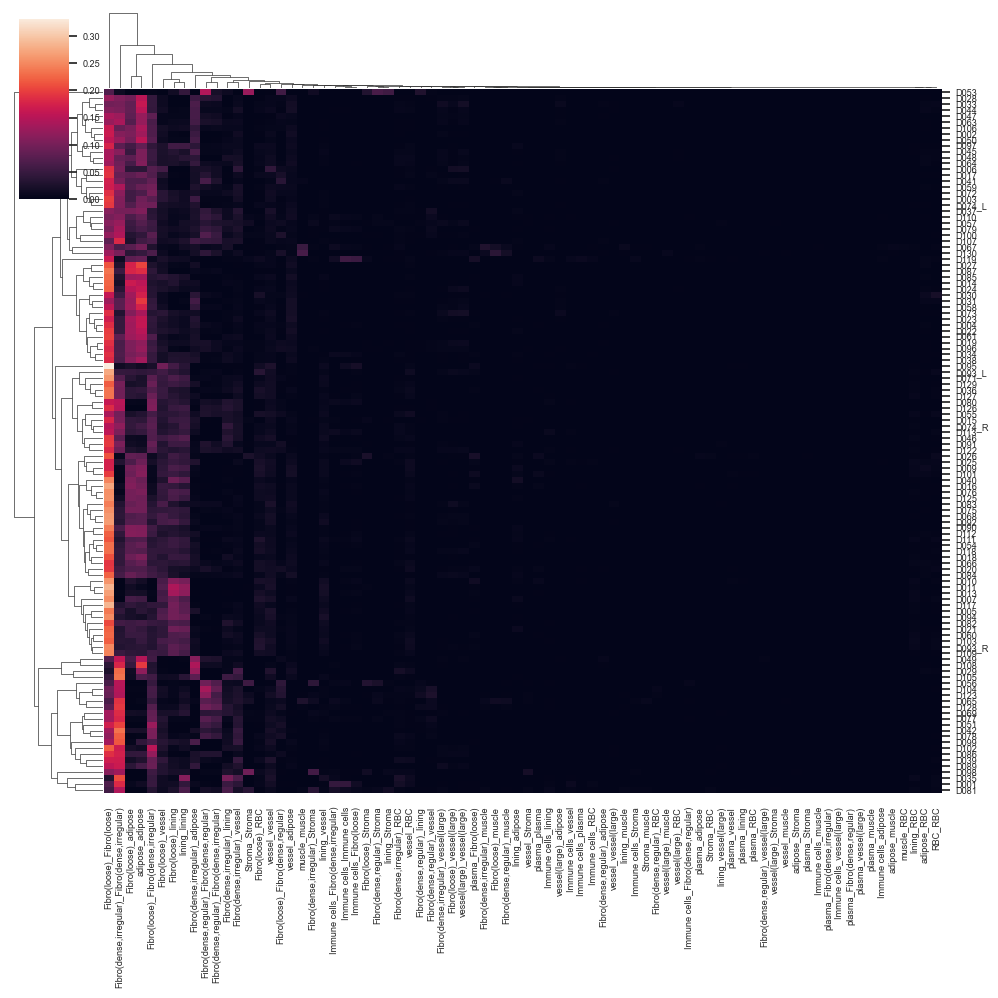

In [77]:
sns.set(font_scale=0.6)
p = sns.clustermap(degree_df, figsize=(10,10),xticklabels=1,yticklabels=1, dendrogram_ratio=(0.1,0.1),)
p.savefig("plots/012_Entropy_degree_ratio_heatmap_241115.pdf", format="pdf")

### 同種接続無し版

In [78]:
triu_list = [ df.values[ np.triu_indices_from(df, k=1) ] for df in AdjMat_dict2.values()]

In [79]:
pd.DataFrame(triu_list)

,0,1,2,3,4,5,6,7,8,9,...,56,57,58,59,60,61,62,63,64,65
0,0.001960,0.048069,0.000089,0.146992,0.011410,0.032347,0.000006,0.000606,0.000030,0.000107,...,0.000861,0.000000,0.000000,0.000244,0.000000,0.000000,0.001616,0.000000,0.000160,0.000048
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001972,0.000000,0.000000,0.000868,0.000000,0.000000,0.003865,0.000000,0.000000,0.000000
2,0.000000,0.000287,0.000000,0.000194,0.000000,0.000111,0.000000,0.000019,0.000000,0.000000,...,0.000065,0.000185,0.000019,0.000009,0.000111,0.000046,0.001499,0.000028,0.000000,0.000000
3,0.002620,0.009488,0.000163,0.001262,0.000529,0.000869,0.000054,0.002946,0.000000,0.000000,...,0.001059,0.000000,0.000000,0.000109,0.000000,0.000000,0.009638,0.000000,0.000000,0.000000
4,0.001451,0.011204,0.000000,0.000008,0.001929,0.002692,0.000000,0.000185,0.000017,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000008,0.001677,0.000000,0.000034,0.000067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,0.000000,0.001472,0.000000,0.000359,0.000969,0.000108,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000215,0.000000,0.000000,0.000215
114,0.000232,0.013239,0.000000,0.004413,0.007716,0.003097,0.000103,0.000077,0.000103,0.000000,...,0.000000,0.000129,0.000000,0.000800,0.000000,0.000103,0.002426,0.000000,0.000000,0.000206
115,0.000066,0.004747,0.001316,0.013989,0.007674,0.001359,0.000011,0.000011,0.000888,0.000296,...,0.000077,0.000099,0.000132,0.000044,0.000011,0.000000,0.000000,0.000417,0.000121,0.000713
116,0.000140,0.008548,0.000000,0.003158,0.004197,0.002316,0.000056,0.000730,0.000000,0.000000,...,0.000014,0.000000,0.000000,0.000140,0.000000,0.000000,0.001797,0.000000,0.000000,0.000000


In [80]:
degree_df2 = pd.DataFrame(triu_list, index=AdjMat_dict2.keys())

### 接続名を列名に入れる

In [81]:
tmp = pd.DataFrame(index=cluster_level,columns=cluster_level)
tmp

,Immune cells,plasma,Fibro(loose),"Fibro(dense,regular)","Fibro(dense,irregular)",lining,vessel,vessel(large),adipose,Stroma,muscle,RBC
Immune cells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plasma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fibro(loose),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Fibro(dense,regular)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Fibro(dense,irregular)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lining,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vessel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vessel(large),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adipose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stroma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
for i in range(len(cluster_level)):
    for j in range(len(cluster_level)):
        term = cluster_level[i] + "_" + cluster_level[j]
        tmp.iloc[i,j] = term

In [83]:
tmp

,Immune cells,plasma,Fibro(loose),"Fibro(dense,regular)","Fibro(dense,irregular)",lining,vessel,vessel(large),adipose,Stroma,muscle,RBC
Immune cells,Immune cells_Immune cells,Immune cells_plasma,Immune cells_Fibro(loose),"Immune cells_Fibro(dense,regular)","Immune cells_Fibro(dense,irregular)",Immune cells_lining,Immune cells_vessel,Immune cells_vessel(large),Immune cells_adipose,Immune cells_Stroma,Immune cells_muscle,Immune cells_RBC
plasma,plasma_Immune cells,plasma_plasma,plasma_Fibro(loose),"plasma_Fibro(dense,regular)","plasma_Fibro(dense,irregular)",plasma_lining,plasma_vessel,plasma_vessel(large),plasma_adipose,plasma_Stroma,plasma_muscle,plasma_RBC
Fibro(loose),Fibro(loose)_Immune cells,Fibro(loose)_plasma,Fibro(loose)_Fibro(loose),"Fibro(loose)_Fibro(dense,regular)","Fibro(loose)_Fibro(dense,irregular)",Fibro(loose)_lining,Fibro(loose)_vessel,Fibro(loose)_vessel(large),Fibro(loose)_adipose,Fibro(loose)_Stroma,Fibro(loose)_muscle,Fibro(loose)_RBC
"Fibro(dense,regular)","Fibro(dense,regular)_Immune cells","Fibro(dense,regular)_plasma","Fibro(dense,regular)_Fibro(loose)","Fibro(dense,regular)_Fibro(dense,regular)","Fibro(dense,regular)_Fibro(dense,irregular)","Fibro(dense,regular)_lining","Fibro(dense,regular)_vessel","Fibro(dense,regular)_vessel(large)","Fibro(dense,regular)_adipose","Fibro(dense,regular)_Stroma","Fibro(dense,regular)_muscle","Fibro(dense,regular)_RBC"
"Fibro(dense,irregular)","Fibro(dense,irregular)_Immune cells","Fibro(dense,irregular)_plasma","Fibro(dense,irregular)_Fibro(loose)","Fibro(dense,irregular)_Fibro(dense,regular)","Fibro(dense,irregular)_Fibro(dense,irregular)","Fibro(dense,irregular)_lining","Fibro(dense,irregular)_vessel","Fibro(dense,irregular)_vessel(large)","Fibro(dense,irregular)_adipose","Fibro(dense,irregular)_Stroma","Fibro(dense,irregular)_muscle","Fibro(dense,irregular)_RBC"
lining,lining_Immune cells,lining_plasma,lining_Fibro(loose),"lining_Fibro(dense,regular)","lining_Fibro(dense,irregular)",lining_lining,lining_vessel,lining_vessel(large),lining_adipose,lining_Stroma,lining_muscle,lining_RBC
vessel,vessel_Immune cells,vessel_plasma,vessel_Fibro(loose),"vessel_Fibro(dense,regular)","vessel_Fibro(dense,irregular)",vessel_lining,vessel_vessel,vessel_vessel(large),vessel_adipose,vessel_Stroma,vessel_muscle,vessel_RBC
vessel(large),vessel(large)_Immune cells,vessel(large)_plasma,vessel(large)_Fibro(loose),"vessel(large)_Fibro(dense,regular)","vessel(large)_Fibro(dense,irregular)",vessel(large)_lining,vessel(large)_vessel,vessel(large)_vessel(large),vessel(large)_adipose,vessel(large)_Stroma,vessel(large)_muscle,vessel(large)_RBC
adipose,adipose_Immune cells,adipose_plasma,adipose_Fibro(loose),"adipose_Fibro(dense,regular)","adipose_Fibro(dense,irregular)",adipose_lining,adipose_vessel,adipose_vessel(large),adipose_adipose,adipose_Stroma,adipose_muscle,adipose_RBC
Stroma,Stroma_Immune cells,Stroma_plasma,Stroma_Fibro(loose),"Stroma_Fibro(dense,regular)","Stroma_Fibro(dense,irregular)",Stroma_lining,Stroma_vessel,Stroma_vessel(large),Stroma_adipose,Stroma_Stroma,Stroma_muscle,Stroma_RBC


In [84]:
columns = tmp.values[ np.triu_indices_from(tmp,k=1) ]

In [85]:
degree_df2.columns = columns
degree_df2

,Immune cells_plasma,Immune cells_Fibro(loose),"Immune cells_Fibro(dense,regular)","Immune cells_Fibro(dense,irregular)",Immune cells_lining,Immune cells_vessel,Immune cells_vessel(large),Immune cells_adipose,Immune cells_Stroma,Immune cells_muscle,...,vessel(large)_adipose,vessel(large)_Stroma,vessel(large)_muscle,vessel(large)_RBC,adipose_Stroma,adipose_muscle,adipose_RBC,Stroma_muscle,Stroma_RBC,muscle_RBC
D001,0.001960,0.048069,0.000089,0.146992,0.011410,0.032347,0.000006,0.000606,0.000030,0.000107,...,0.000861,0.000000,0.000000,0.000244,0.000000,0.000000,0.001616,0.000000,0.000160,0.000048
D002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001972,0.000000,0.000000,0.000868,0.000000,0.000000,0.003865,0.000000,0.000000,0.000000
D003,0.000000,0.000287,0.000000,0.000194,0.000000,0.000111,0.000000,0.000019,0.000000,0.000000,...,0.000065,0.000185,0.000019,0.000009,0.000111,0.000046,0.001499,0.000028,0.000000,0.000000
D004,0.002620,0.009488,0.000163,0.001262,0.000529,0.000869,0.000054,0.002946,0.000000,0.000000,...,0.001059,0.000000,0.000000,0.000109,0.000000,0.000000,0.009638,0.000000,0.000000,0.000000
D005,0.001451,0.011204,0.000000,0.000008,0.001929,0.002692,0.000000,0.000185,0.000017,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000008,0.001677,0.000000,0.000034,0.000067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D126,0.000000,0.001472,0.000000,0.000359,0.000969,0.000108,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000215,0.000000,0.000000,0.000215
D127,0.000232,0.013239,0.000000,0.004413,0.007716,0.003097,0.000103,0.000077,0.000103,0.000000,...,0.000000,0.000129,0.000000,0.000800,0.000000,0.000103,0.002426,0.000000,0.000000,0.000206
D128,0.000066,0.004747,0.001316,0.013989,0.007674,0.001359,0.000011,0.000011,0.000888,0.000296,...,0.000077,0.000099,0.000132,0.000044,0.000011,0.000000,0.000000,0.000417,0.000121,0.000713
D129,0.000140,0.008548,0.000000,0.003158,0.004197,0.002316,0.000056,0.000730,0.000000,0.000000,...,0.000014,0.000000,0.000000,0.000140,0.000000,0.000000,0.001797,0.000000,0.000000,0.000000


### 全症例で次数比率0のものは除く

In [86]:
(degree_df2.sum(axis=0) == 0).value_counts()

False    66
Name: count, dtype: int64

In [87]:
degree_df2.columns[np.where(degree_df2.sum(axis=0) == 0)]

Index([], dtype='object')

In [100]:
degree_df2.loc[:,degree_df2.sum(axis=0) != 0].shape

(118, 88)

In [88]:
degree_df2 = degree_df2.loc[:,degree_df2.sum(axis=0) != 0]

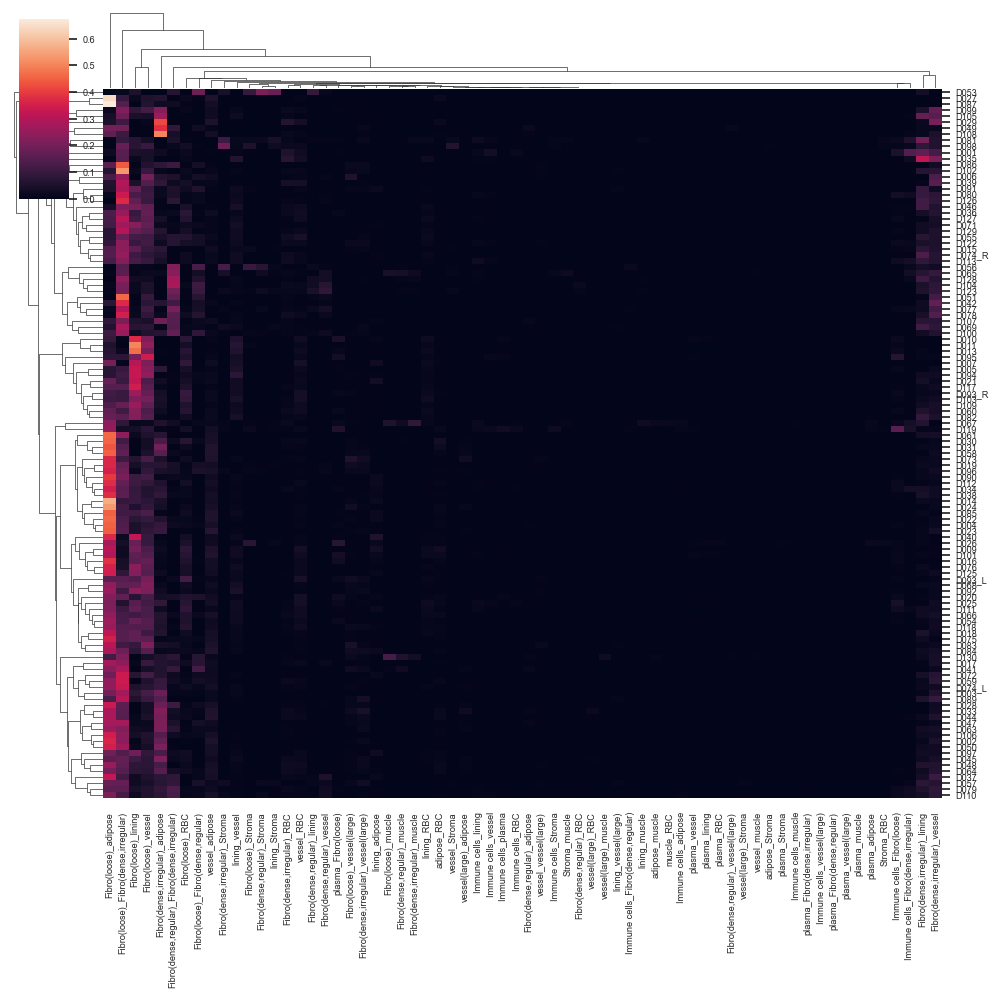

In [89]:
sns.set(font_scale=0.6)
p = sns.clustermap(degree_df2, figsize=(10,10),xticklabels=1,yticklabels=1, dendrogram_ratio=(0.1,0.1),)
p.savefig("plots/013_Entropy_degree2_ratio_heatmap_241115.pdf", format="pdf")

In [90]:
degree_df.to_csv("Degree_df_241115.csv")
degree_df2.to_csv("Degree_df2_241115.csv")